# Decision Trees and Random Forests in Python

Reference: http://net-informations.com/ds/mla/dtree.htm, https://www.kaggle.com/code

Credit (Image) from https://www.osmosis.org/learn/Lordosis,_kyphosis,_and_scoliosis

![](https://d16qt3wv6xm098.cloudfront.net/D8vzGbPOSmitZdUZkrleQYi-SZ6ZFOpZ/_.jpg)

# Install this package before starting this lab

## Import Libraries

In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Get the Data

In [121]:
!wget --no-check-certificate https://github.com/davidjohnnn/all_datasets/raw/master/bay/kyphosis.csv

--2026-01-21 11:49:09--  https://github.com/davidjohnnn/all_datasets/raw/master/bay/kyphosis.csv
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/davidjohnnn/all_datasets/master/bay/kyphosis.csv [following]
--2026-01-21 11:49:10--  https://raw.githubusercontent.com/davidjohnnn/all_datasets/master/bay/kyphosis.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1430 (1.4K) [text/plain]
Saving to: ‘kyphosis.csv.1’

kyphosis.csv.1      100%[===================>]   1.40K  --.-KB/s    in 0s      

2026-01-21 11:49:10 (20.0 MB/s) - ‘kyphosis.csv.1’ saved [1430/1430]



In [122]:
df = pd.read_csv('kyphosis.csv')

In [123]:
df.head()

,Kyphosis,Age,Number,Start
0,absent,71,3,5
1,absent,158,3,14
2,present,128,4,5
3,absent,2,5,1
4,absent,1,4,15


## EDA

We'll just check out a simple pairplot for this small dataset.

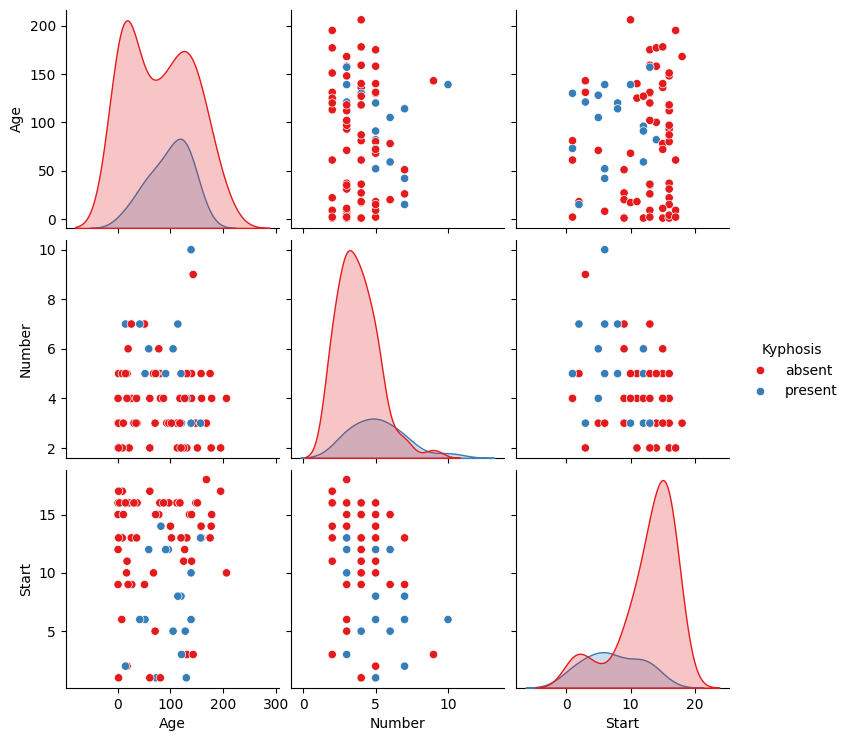

In [124]:
sns.pairplot(df,hue='Kyphosis',palette='Set1')

## Train Test Split

Let's split up the data into a training set and a test set!

In [125]:
from sklearn.model_selection import train_test_split

In [126]:
X = df.drop('Kyphosis',axis=1)
y = df['Kyphosis']

In [127]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.30, random_state=30)

## Decision Trees

We'll start just by training a single decision tree.

http://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier

In [128]:
from sklearn.tree import DecisionTreeClassifier

In [129]:
dtree = DecisionTreeClassifier(min_samples_leaf=10, criterion='entropy')

In [130]:
dtree.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', min_samples_leaf=10)

In [131]:
import pickle
filename = 'model.sav'
pickle.dump(dtree, open(filename, 'wb'))

## Prediction and Evaluation

Let's evaluate our decision tree.

In [132]:
dtree = pickle.load(open(filename,'rb'))
dtree

DecisionTreeClassifier(criterion='entropy', min_samples_leaf=10)

In [133]:
predictions = dtree.predict(X_test)

In [134]:
from sklearn.metrics import classification_report,confusion_matrix

In [135]:
print(classification_report(y_test,predictions,digits=4))

              precision    recall  f1-score   support

      absent     0.9000    0.9000    0.9000        20
     present     0.6000    0.6000    0.6000         5

    accuracy                         0.8400        25
   macro avg     0.7500    0.7500    0.7500        25
weighted avg     0.8400    0.8400    0.8400        25



In [136]:
print(confusion_matrix(y_test,predictions,labels=['absent','present']))

[[18  2]
 [ 2  3]]


## Tree Visualization

Scikit learn actually has some built-in visualization capabilities for decision trees, you won't use this often and it requires you to install the pydot library, but here is an example of what it looks like and the code to execute this:

[Text(0.6, 0.875, 'x[2] <= 14.5\nentropy = 0.75\nsamples = 56\nvalue = [44, 12]'),
 Text(0.4, 0.625, 'x[0] <= 38.5\nentropy = 0.928\nsamples = 35\nvalue = [23, 12]'),
 Text(0.5, 0.75, 'True  '),
 Text(0.2, 0.375, 'entropy = 0.439\nsamples = 11\nvalue = [10, 1]'),
 Text(0.6, 0.375, 'x[0] <= 123.0\nentropy = 0.995\nsamples = 24\nvalue = [13, 11]'),
 Text(0.4, 0.125, 'entropy = 0.985\nsamples = 14\nvalue = [6, 8]'),
 Text(0.8, 0.125, 'entropy = 0.881\nsamples = 10\nvalue = [7, 3]'),
 Text(0.8, 0.625, 'entropy = 0.0\nsamples = 21\nvalue = [21, 0]'),
 Text(0.7, 0.75, '  False')]

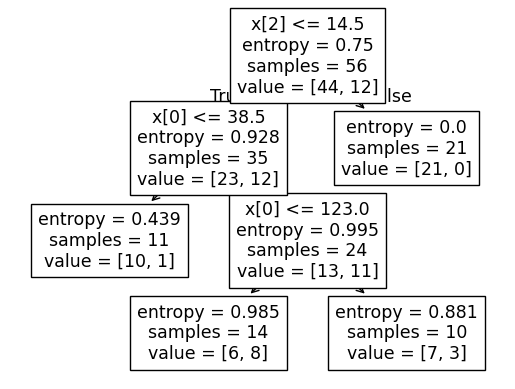

In [137]:
from sklearn import tree
tree.plot_tree(dtree)

In [138]:
print(X.columns) # feature names
print(y.unique().tolist()) # class names

Index(['Age', 'Number', 'Start'], dtype='object')
['absent', 'present']


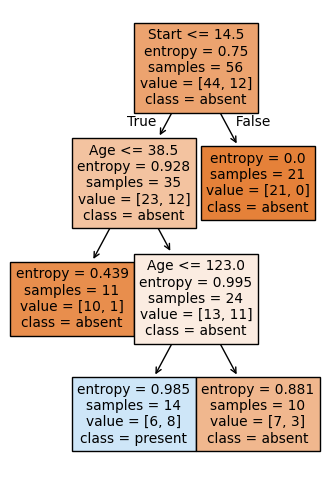

In [139]:
fn=X.columns # feature names
cn=y.unique().tolist() # class names
fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,6), dpi=100)
tree.plot_tree(dtree,
               feature_names = fn,
               class_names=cn,
               filled = True);
fig.savefig('imagename.png')

# Tree

In [140]:
dtree.feature_importances_

array([0.34552811, 0.        , 0.65447189])

**Use gini instead Entropy because target feature is imbalnace**

In [141]:
d_tree1 = DecisionTreeClassifier(min_samples_leaf=10, criterion="gini")
d_tree1.fit(X_train, y_train)
y_pred = d_tree1.predict(X_test)

In [142]:
response = (classification_report(y_test, y_pred, digits=4, output_dict=True))
response

{'absent': {'precision': 0.9473684210526315,
  'recall': 0.9,
  'f1-score': 0.9230769230769231,
  'support': 20.0},
 'present': {'precision': 0.6666666666666666,
  'recall': 0.8,
  'f1-score': 0.7272727272727273,
  'support': 5.0},
 'accuracy': 0.88,
 'macro avg': {'precision': 0.8070175438596491,
  'recall': 0.8500000000000001,
  'f1-score': 0.8251748251748252,
  'support': 25.0},
 'weighted avg': {'precision': 0.8912280701754385,
  'recall': 0.88,
  'f1-score': 0.883916083916084,
  'support': 25.0}}

In [143]:
d_tree1.feature_importances_

array([0.1128675, 0.       , 0.8871325])

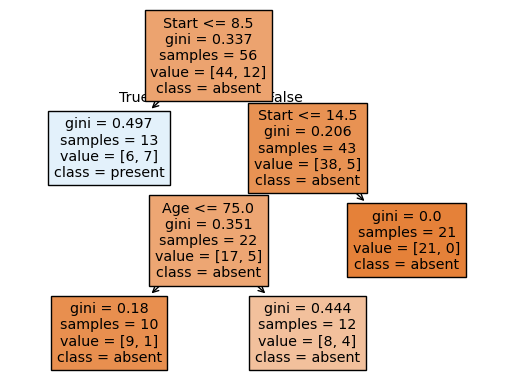

In [144]:
tree.plot_tree(d_tree1,
               feature_names = fn,
               class_names=cn,
               filled = True);

**Now try to change another parameters**

In [184]:
min_sample_leaf = [2,5,10,15,20,25,30]
max_leaf_nodes = [2,5,10,15,20,25,30]
max_depth = [2,5,10,15,20,25,30]
max_feature = [None, "sqrt", "log2", 0.2, 0.6, 0.8]
f1_score = []
best_model = None
best_score = 0
for ml in min_sample_leaf:
  for mln in max_leaf_nodes:
    for md in max_depth:
      for mf in max_feature:
        d_tree1 = DecisionTreeClassifier(min_samples_leaf=ml, criterion="gini", max_depth=md, max_leaf_nodes=mln, max_features=mf)
        d_tree1.fit(X_train, y_train)
        y_pred = d_tree1.predict(X_test)
        result = classification_report(y_test,y_pred, output_dict=True, digits=True)
        if best_model is None or result["macro avg"]["f1-score"] > best_score:
          best_model = d_tree1
          best_score = result["macro avg"]["f1-score"]
        f1_score.append({
            "min_sample_leaf": ml,
            "max_leaf_nodes": mln,
            "max_depth": md,
            "max_feature": mf,
            "f1_score": result["macro avg"]["f1-score"]
        })

เอาต์พุตของการสตรีมมีการตัดเหลือเพียง 5000 บรรทัดสุดท้าย
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(r

In [185]:
df_result = pd.DataFrame(f1_score)

In [195]:
df_result[df_result["f1_score"] > 0.83]

,min_sample_leaf,max_leaf_nodes,max_depth,max_feature,f1_score
159,2,15,25,0.2,0.875
182,2,20,10,log2,0.875
185,2,20,10,0.8,0.875


In [197]:
df_result[df_result["f1_score"] > 0.82]

,min_sample_leaf,max_leaf_nodes,max_depth,max_feature,f1_score
2,2,2,2,log2,0.825175
3,2,2,2,0.2,0.825175
7,2,2,5,sqrt,0.825175
8,2,2,5,log2,0.825175
19,2,2,15,sqrt,0.825175
...,...,...,...,...,...
870,10,30,25,None,0.825175
874,10,30,25,0.6,0.825175
875,10,30,25,0.8,0.825175
876,10,30,30,None,0.825175


In [187]:
param = df_result[df_result["f1_score"] == df_result["f1_score"].max()]

In [188]:
param

,min_sample_leaf,max_leaf_nodes,max_depth,max_feature,f1_score
159,2,15,25,0.2,0.875
182,2,20,10,log2,0.875
185,2,20,10,0.8,0.875


In [189]:
best_model

DecisionTreeClassifier(max_depth=25, max_features=0.2, max_leaf_nodes=15,
                       min_samples_leaf=2)

In [190]:
print(classification_report(y_test, best_model.predict(X_test), digits=4))

              precision    recall  f1-score   support

      absent     0.9500    0.9500    0.9500        20
     present     0.8000    0.8000    0.8000         5

    accuracy                         0.9200        25
   macro avg     0.8750    0.8750    0.8750        25
weighted avg     0.9200    0.9200    0.9200        25



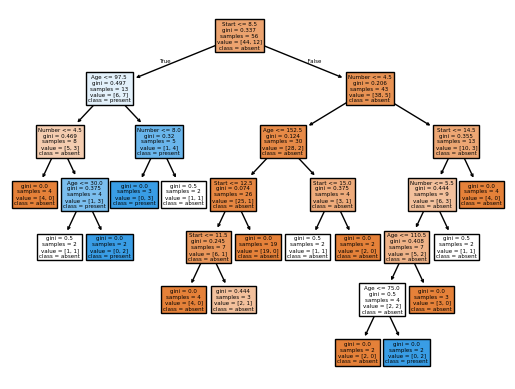

In [191]:
tree.plot_tree(best_model,
               feature_names = fn,
               class_names=cn,
               filled = True);

**f1_score for small model is only 0.825175 but large model is 5% better. therefor, I select the model with 0.875 f1-score**

# RandomForest

In [198]:
from sklearn.ensemble import RandomForestClassifier

In [230]:
min_sample_leaf = [2,5,10]
max_depth = [5,10,20]
max_feature = [None, "sqrt", "log2", 0.5]
nestimator = [20,50,100, 200]
f1_score = []
best_model = None
best_score = 0
for ml in min_sample_leaf:
  for md in max_depth:
    for mf in max_feature:
      for nm in nestimator:
        d_tree1 = RandomForestClassifier(n_estimators= nm, min_samples_leaf=ml, criterion="gini", max_depth=md, max_features=mf, random_state=30)
        d_tree1.fit(X_train, y_train)
        y_pred = d_tree1.predict(X_test)
        result = classification_report(y_test,y_pred, output_dict=True, digits=True)
        if best_model is None or result["macro avg"]["f1-score"] > best_score:
          best_model = d_tree1
          best_score = result["macro avg"]["f1-score"]
        f1_score.append({
            "min_sample_leaf": ml,
            "max_depth": md,
            "max_feature": mf,
            "n_estimators": nm,
            "f1_score": result["macro avg"]["f1-score"]
        })

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [231]:
best_model

RandomForestClassifier(max_depth=5, max_features=None, min_samples_leaf=5,
                       n_estimators=20, random_state=30)

In [232]:
best_model.n_estimators

20

In [233]:
result_forest = pd.DataFrame(f1_score)
result_forest

,min_sample_leaf,max_depth,max_feature,n_estimators,f1_score
0,2,5,None,20,0.661247
1,2,5,None,50,0.708625
2,2,5,None,100,0.525745
3,2,5,None,200,0.553571
4,2,5,sqrt,20,0.584718
...,...,...,...,...,...
139,10,20,log2,200,0.444444
140,10,20,0.5,20,0.444444
141,10,20,0.5,50,0.444444
142,10,20,0.5,100,0.444444


In [234]:
result_forest[result_forest['f1_score'] == result_forest['f1_score'].max()]

,min_sample_leaf,max_depth,max_feature,n_estimators,f1_score
48,5,5,None,20,0.85119
64,5,10,None,20,0.85119
80,5,20,None,20,0.85119


In [235]:
best_model.feature_importances_

array([0.23505973, 0.24290372, 0.52203654])

In [239]:
result_forest[result_forest['f1_score'] > 0.75]

,min_sample_leaf,max_depth,max_feature,n_estimators,f1_score
48,5,5,None,20,0.851190
49,5,5,None,50,0.750831
50,5,5,None,100,0.750831
51,5,5,None,200,0.750831
64,5,10,None,20,0.851190
65,5,10,None,50,0.750831
66,5,10,None,100,0.750831
67,5,10,None,200,0.750831
80,5,20,None,20,0.851190
81,5,20,None,50,0.750831


In [260]:
# Try to adjust seed for ensuring that model which n_estimator equal 20 is lucky
after_switch_seed = [30,42,123,300]
result_after = []
for seed in after_switch_seed:
  for val in result_forest[result_forest['f1_score'] > 0.75].values:
    d_tree1 = RandomForestClassifier(n_estimators= val[3], min_samples_leaf=val[0], criterion="gini", max_depth=val[1], max_features= (val[2] if val[2] != None else None), random_state=seed)
    d_tree1.fit(X_train, y_train)
    y_pred = d_tree1.predict(X_test)
    result = classification_report(y_test,y_pred, output_dict=True, digits=True)
    result_after.append({
        "min_sample_leaf": val[0],
        "max_depth": val[1],
        "max_feature": (val[2] if val[2] != None else None),
        "n_estimators": val[3],
        "f1_score": result["macro avg"]["f1-score"],
        "seed": seed}
    )

In [261]:
pd_real_result = pd.DataFrame(result_after)

In [267]:
pd_real_result.head()

,min_sample_leaf,max_depth,max_feature,n_estimators,f1_score,seed
0,5,5,None,20,0.851190,30
1,5,5,None,50,0.750831,30
2,5,5,None,100,0.750831,30
3,5,5,None,200,0.750831,30
4,5,10,None,20,0.851190,30


In [266]:
pd_real_result[(pd_real_result["f1_score"] == pd_real_result["f1_score"].max()) & (pd_real_result["seed"] != 30)]

,min_sample_leaf,max_depth,max_feature,n_estimators,f1_score,seed


**Although the model with fewer estimators achieved the highest initial F1-score, it showed high variance when the random seed was changed. Therefore, I selected the model with 100-200 estimators, as the ensemble averaging provides a more stable and robust result**